In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [12]:
import glob
csv_files = glob.glob('/Users/krishnakishore/Downloads/IDX/*.csv')

In [13]:
df_list = []
for file in csv_files:
    df = pd.read_csv(file)
    df_list.append(df)
merged_df = pd.concat(df_list, ignore_index=True)

/var/folders/1f/krwy3h6948n5qhc5csbfcdph0000gp/T/ipykernel_79374/3448049625.py:3: DtypeWarning: Columns (78,79) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


In [14]:
merged_df.to_csv('merged_file.csv', index=False)

In [54]:
# 1. Filter only Residential & SingleFamilyResidence
df = merged_df[(merged_df['PropertyType'] == 'Residential') & (merged_df['PropertySubType'] == 'SingleFamilyResidence') & (df['StateOrProvince'] == 'CA')]

In [55]:
df.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled
11,SanDiego,SanDiego,"Carpet,Tile",False,NaN,NaN,False,530000.0,1104130366,tom@structuresd.com,...,NaN,False,0.0,NaN,92021,NaN,13800.0,NaN,False,False
12,SanDiego,SanDiego,NaN,False,NaN,NaN,False,700000.0,1104128744,chadtrower@gmail.com,...,NaN,False,0.0,NaN,92124,170.0,3000.0,NaN,False,False
13,SanDiego,SanDiego,"Carpet,Tile",False,NaN,NaN,False,1680000.0,1104128653,lisa@premiercoastalrealty.com,...,NaN,False,2.0,NaN,92130,26.0,NaN,NaN,False,False
14,CaliforniaDesert,CaliforniaDesert,Tile,True,NaN,NaN,True,1195000.0,1104128077,lisa@traditionproperties.net,...,NaN,False,3.0,NaN,92253,275.0,11761.0,NaN,False,False
16,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,NaN,True,NaN,NaN,NaN,3800000.0,1104126716,Djacobson.re@gmail.com,...,NaN,False,NaN,NaN,91423,NaN,15365.0,NaN,False,False


In [56]:
df.describe()

,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,AboveGradeFinishedArea,...,ElementarySchoolDistrict,BelowGradeFinishedArea,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
count,2.470440e+05,2.475200e+05,2.475200e+05,247504.000000,247504.000000,247376.000000,2.475200e+05,247520.000000,0.0,0.0,...,0.0,1564.000000,0.0,217192.000000,2.430400e+05,149128.000000,238156.000000,174316.000000,2.430320e+05,0.0
mean,1.371961e+06,1.099151e+09,1.291401e+06,34.735600,-118.612129,2035.803097,1.263327e+06,37.711037,NaN,NaN,...,NaN,78.498721,NaN,1.350657,2.436132e+04,2.271632,1.990082,104.325477,1.777146e+05,NaN
std,8.247894e+06,1.165554e+07,4.851797e+06,1.738912,3.069139,1039.423548,1.551803e+06,50.913905,NaN,NaN,...,NaN,363.473883,NaN,0.477177,1.032834e+06,2.679748,2.615212,331.672324,1.275589e+07,NaN
min,0.000000e+00,4.866162e+08,1.150000e+00,0.000000,-124.192979,0.000000,2.500000e+04,-34.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,NaN
25%,6.299000e+05,1.093424e+09,6.249000e+05,33.758888,-119.168613,1379.000000,6.249000e+05,8.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,5.499000e+03,1.000000,2.000000,0.000000,5.663000e+03,NaN
50%,8.990000e+05,1.102567e+09,8.900000e+05,34.077804,-118.017914,1803.000000,8.900000e+05,18.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,7.140000e+03,3.000000,2.000000,0.000000,7.258000e+03,NaN
75%,1.444900e+06,1.107817e+09,1.435000e+06,34.854142,-117.255497,2421.000000,1.399999e+06,49.000000,NaN,NaN,...,NaN,0.000000,NaN,2.000000,9.957250e+03,3.000000,2.000000,130.000000,1.035000e+04,NaN
max,1.390000e+09,1.114761e+09,9.700000e+08,41.971535,329.000000,33652.000000,1.100000e+08,966.000000,NaN,NaN,...,NaN,4224.000000,NaN,2.000000,2.178000e+08,444.000000,400.000000,19918.000000,2.087221e+09,NaN


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 247520 entries, 11 to 502163
Data columns (total 80 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 247504 non-null  object 
 1   ListAgentAOR                  247504 non-null  object 
 2   Flooring                      158240 non-null  object 
 3   ViewYN                        225988 non-null  object 
 4   WaterfrontYN                  148 non-null     object 
 5   BasementYN                    5940 non-null    object 
 6   PoolPrivateYN                 225844 non-null  object 
 7   OriginalListPrice             247044 non-null  float64
 8   ListingKey                    247520 non-null  int64  
 9   ListAgentEmail                246664 non-null  object 
 10  CloseDate                     247520 non-null  object 
 11  ClosePrice                    247520 non-null  float64
 12  ListAgentFirstName            245756 non-null  o

In [58]:
# 2. Data Exploration
print("Shape of data:", df.shape)
print("Columns with missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nSample rows:\n", df[['ClosePrice', 'LivingArea', 'ListPrice', 'BedroomsTotal', 'BathroomsTotalInteger', 'YearBuilt']].head())

Shape of data: (247520, 80)
Columns with missing values:
 BuyerAgentAOR                       16
ListAgentAOR                        16
Flooring                         89280
ViewYN                           21532
WaterfrontYN                    247372
                                 ...  
AssociationFee                   73204
LotSizeSquareFeet                 4488
MiddleOrJuniorSchoolDistrict    247520
latfilled                       214948
lonfilled                       214948
Length: 62, dtype: int64

Sample rows:
     ClosePrice  LivingArea  ListPrice  BedroomsTotal  BathroomsTotalInteger  \
11    530000.0      1656.0   530000.0            4.0                    2.0   
12    700000.0      1558.0   700000.0            4.0                    2.0   
13   1680000.0      2286.0  1680000.0            4.0                    3.0   
14   1195000.0      2695.0  1195000.0            3.0                    3.0   
16   3800000.0         NaN  3800000.0            4.0                    5.0   

In [59]:
# Drop columns not known to the end user
drop_cols = [
    'ListingKey', 'ListingKeyNumeric', 'ListAgentEmail', 'ListAgentFirstName', 'ListAgentLastName',
    'ListAgentFullName', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'BuyerAgentMlsId',
    'BuyerOfficeName', 'ListOfficeName', 'CoListOfficeName', 'ListPrice', 'OriginalListPrice',
    'CloseDate', 'ContractStatusChangeDate', 'PurchaseContractDate', 'ListingContractDate',
    'UnparsedAddress', 'ListingId', 'StreetNumberNumeric', 'BusinessType'
]
df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True, errors='ignore')

/var/folders/1f/krwy3h6948n5qhc5csbfcdph0000gp/T/ipykernel_79374/718827863.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True, errors='ignore')


In [60]:
# Drop columns that are entirely missing or nearly constant
# Drop columns with more than 50% missing values
df = df.dropna(axis=1, thresh=0.25*len(df))

In [61]:
# Remove missing target values
df.dropna(subset=['ClosePrice'], inplace=True)

In [62]:
df.shape

(247520, 37)

In [63]:
# Keep only user-available features
features = [
    'ClosePrice', 'LivingArea', 'LotSizeAcres', 'GarageSpaces', 'FireplacesTotal',
    'BathroomsTotalInteger', 'BedroomsTotal', 'Stories', 'YearBuilt',
    'PostalCode', 'StateOrProvince'
]
df = df[[col for col in features if col in df.columns]]

In [64]:
df.shape

(247520, 10)

In [65]:

# Explore missing values
print(df.isnull().sum())

# Summary statistics
print(df.describe())

ClosePrice                   0
LivingArea                 144
LotSizeAcres              4504
GarageSpaces              9364
BathroomsTotalInteger       36
BedroomsTotal                0
Stories                  30328
YearBuilt                  228
PostalCode                   0
StateOrProvince              0
dtype: int64
         ClosePrice     LivingArea   LotSizeAcres   GarageSpaces  \
count  2.475200e+05  247376.000000  243016.000000  238156.000000   
mean   1.291401e+06    2035.803097       6.092086       1.990082   
std    4.851797e+06    1039.423548     458.453225       2.615212   
min    1.150000e+00       0.000000       0.000000       0.000000   
25%    6.249000e+05    1379.000000       0.130000       2.000000   
50%    8.900000e+05    1803.000000       0.166600       2.000000   
75%    1.435000e+06    2421.000000       0.237600       2.000000   
max    9.700000e+08   33652.000000   67790.155600     400.000000   

       BathroomsTotalInteger  BedroomsTotal        Stories      

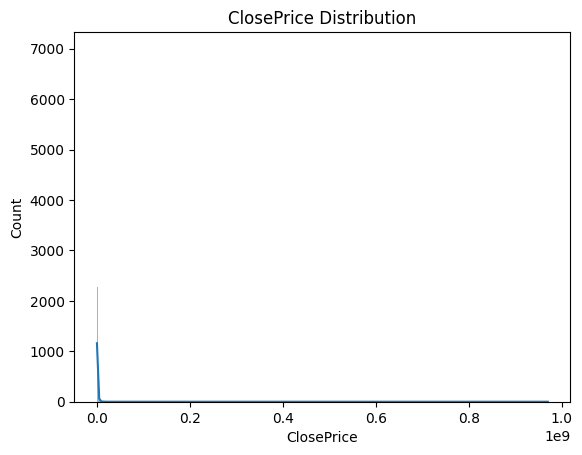

In [66]:
# Distribution of target
sns.histplot(df['ClosePrice'], kde=True)
plt.title('ClosePrice Distribution')
plt.show()

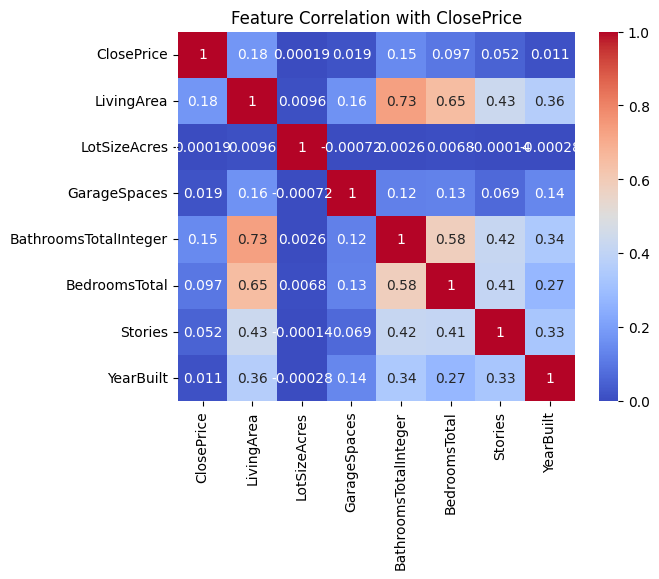

In [67]:
# Correlation heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation with ClosePrice")
plt.show()

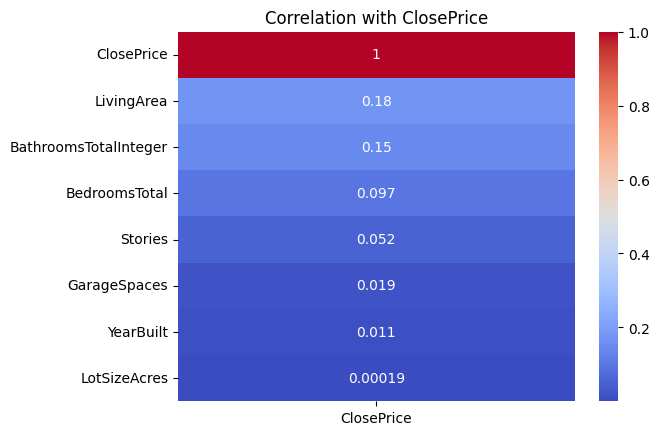

In [68]:
numerical_df = df.select_dtypes(include=['int64', 'float64'])
corr = numerical_df.corr()
sns.heatmap(corr[['ClosePrice']].sort_values(by='ClosePrice', ascending=False), annot=True, cmap='coolwarm')
plt.title("Correlation with ClosePrice")
plt.show()

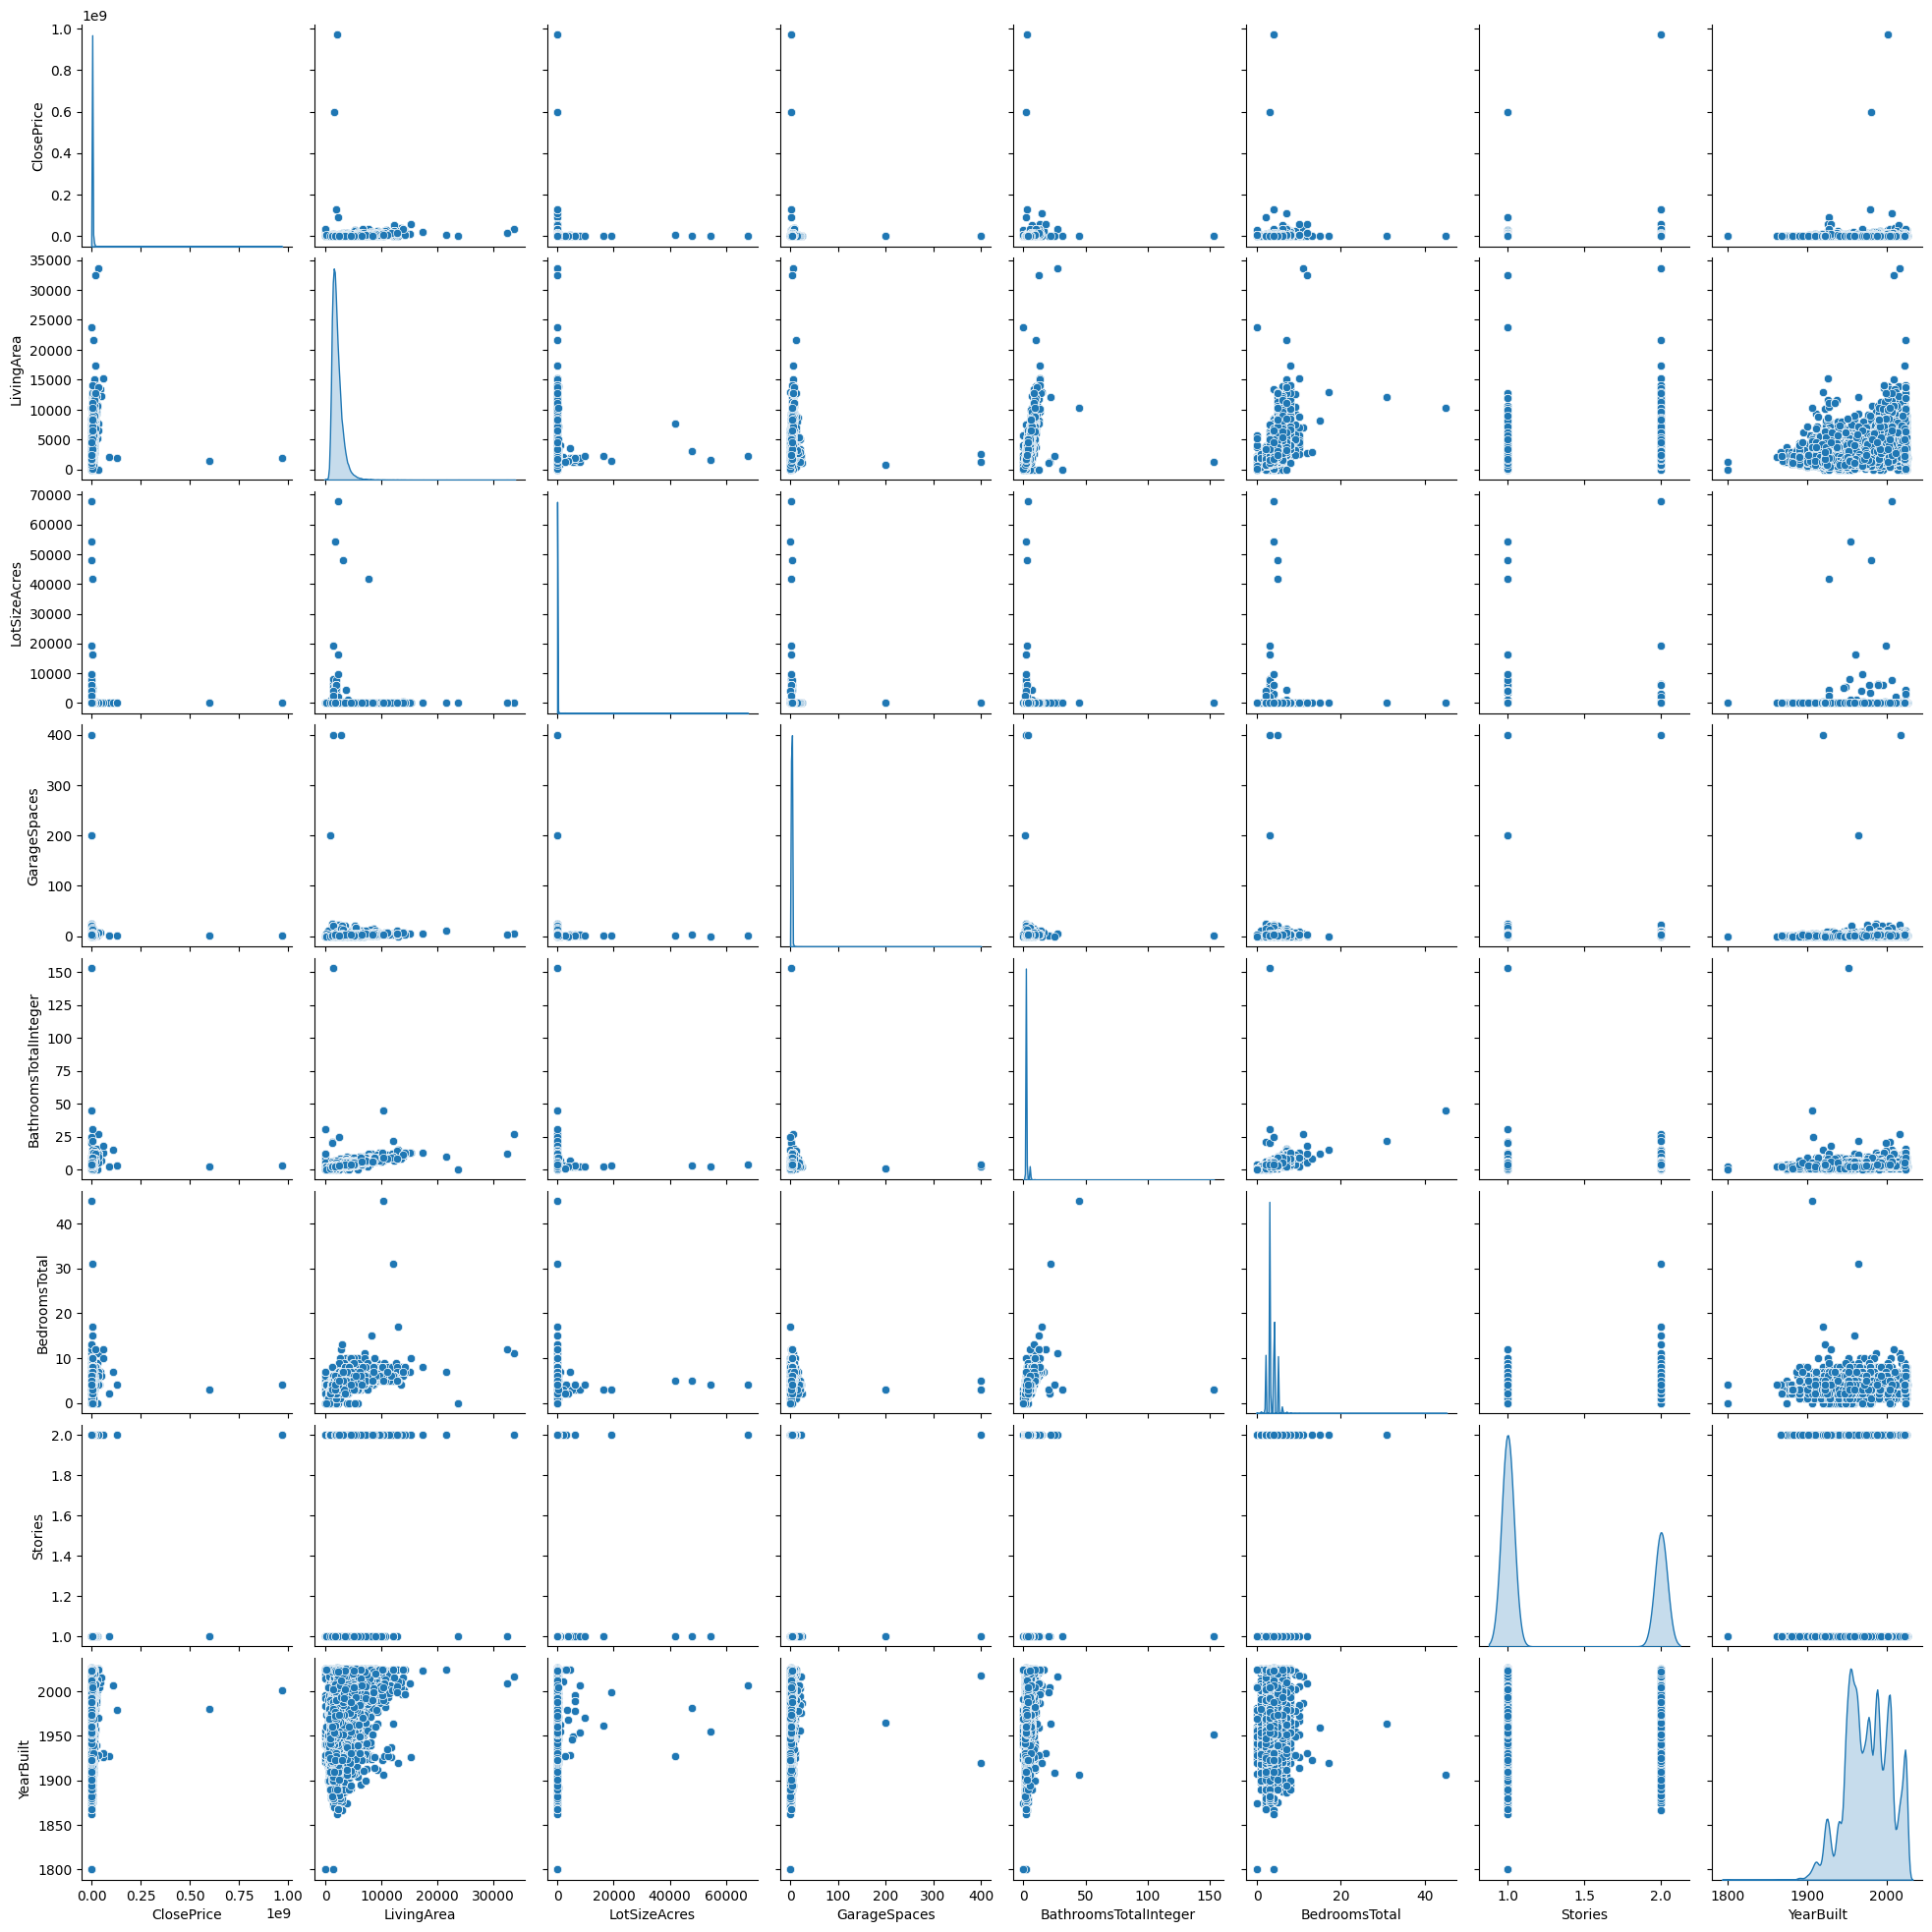

In [69]:
# Pairplot
sns.pairplot(df.drop(columns=['PostalCode', 'StateOrProvince']), diag_kind='kde')
plt.show()


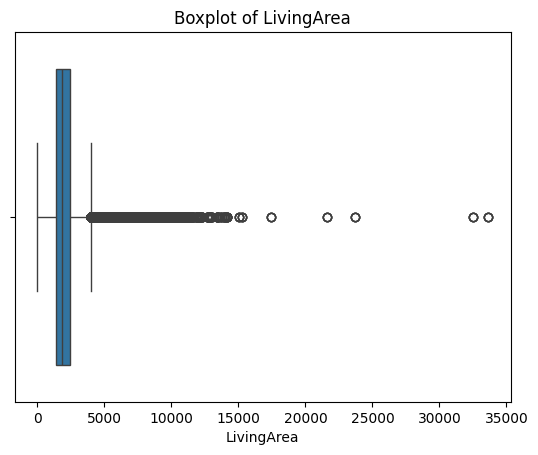

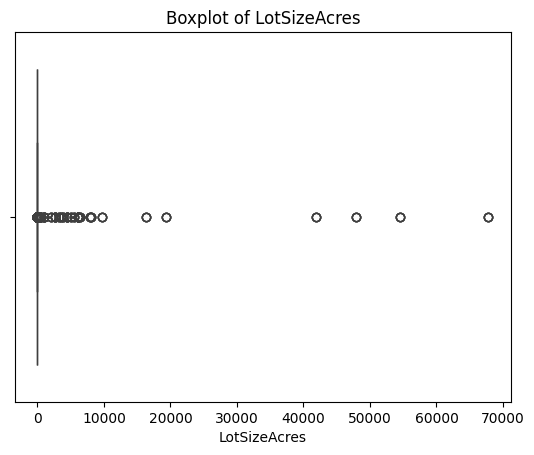

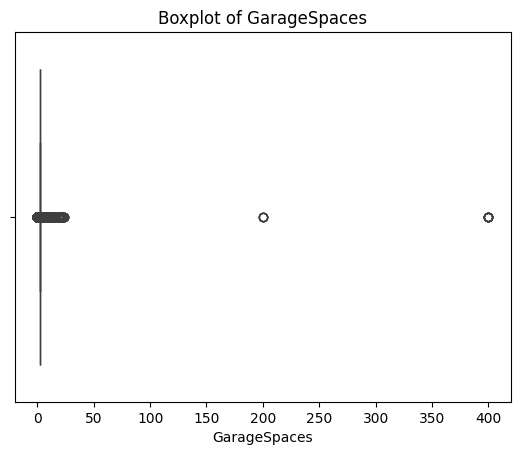

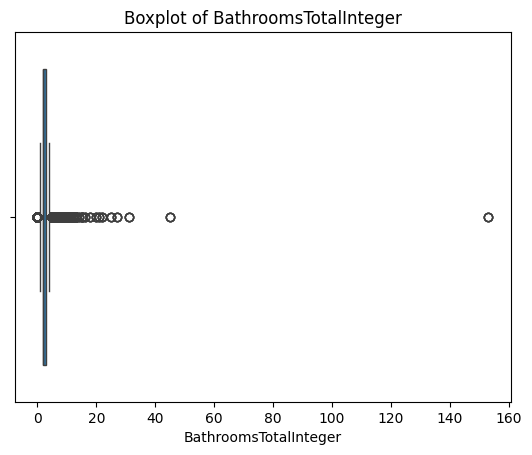

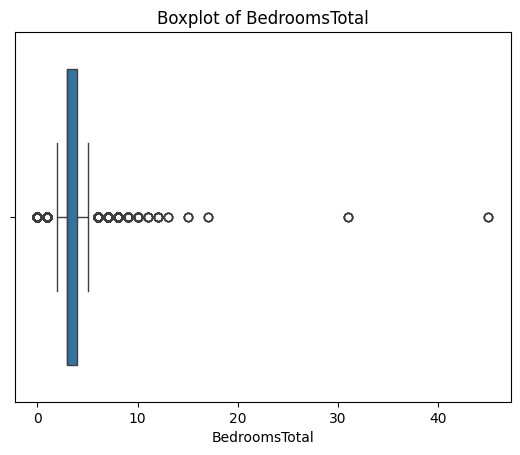

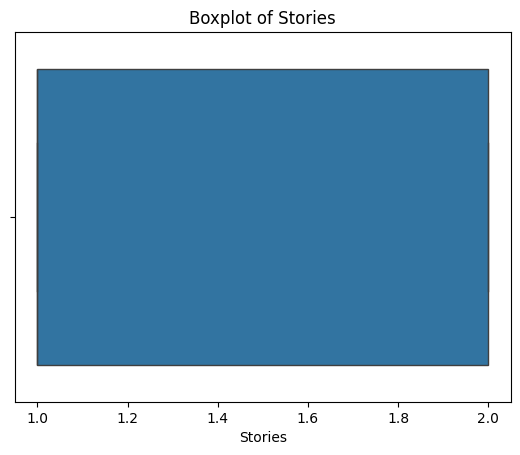

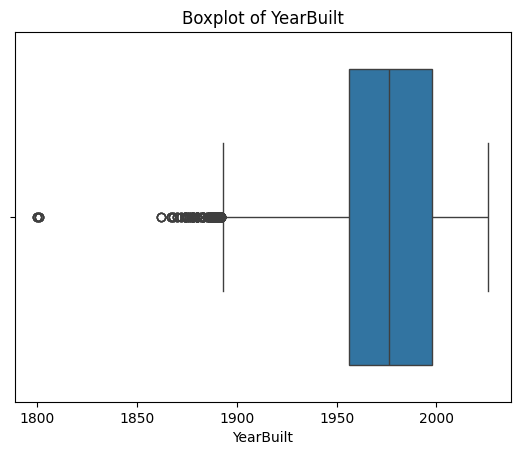

In [70]:
# Outlier boxplots
num_cols = ['LivingArea', 'LotSizeAcres', 'GarageSpaces','BathroomsTotalInteger', 'BedroomsTotal', 'Stories', 'YearBuilt']
for col in num_cols:
    if col in df.columns:
        sns.boxplot(x=df[col])
        plt.title(f'Boxplot of {col}')
        plt.show()

In [71]:
# Impute missing values
imputer = SimpleImputer(strategy='median')
df[num_cols] = imputer.fit_transform(df[num_cols])

In [72]:
# Value counts for top categorical fields
for col in df.select_dtypes(include='object').columns[:5]:
    print(f"\n* Value counts for {col}:\n", df[col].value_counts().head(5))


* Value counts for PostalCode:
 PostalCode
92253    2116
92223    1444
92584    1384
92345    1364
92596    1320
Name: count, dtype: int64

* Value counts for StateOrProvince:
 StateOrProvince
CA    247520
Name: count, dtype: int64


In [73]:
# Encode categorical
df = pd.get_dummies(df, columns=['PostalCode'], drop_first=True)

In [74]:
# Scale numeric
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [75]:
# Train/test split
X = df.drop(columns='ClosePrice')
y = df['ClosePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [76]:
X_train.shape

(198016, 1619)

In [77]:
X_test.shape

(49504, 1619)

***********************************************************************************************